In [ ]:
#Executar apenas a primeira vez
!pip install -U ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
df = pd.read_csv('./treino.csv', encoding='latin1')

/tmp/ipykernel_8561/1947923101.py:2: DtypeWarning: Columns (36,38,44,60,93) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./treino.csv', encoding='latin1')


In [ ]:
# 1. Definir a lista final de preditores (incluindo o alvo ltfu para a análise de correlação)
preditores_selecionados = [
    'idade_anos','CS_SEXO','CS_GESTANT','CS_RACA','CS_ESCOL_N',
    'SG_UF','ID_MN_RESI', 'TRATAMENTO', 'POP_LIBER', 'POP_RUA',
    'POP_SAUDE', 'POP_IMIG', 'FORMA', 'AGRAVALCOO', 'AGRAVDIABE',
    'AGRAVDOENC', 'AGRAVOUTRA', 'HIV', 'DT_INIC_TR', 'SG_UF_2',
    'ID_MUNIC_2', 'TRATSUP_AT', 'TRANSF', 'MUN_TRANSF', 'ltfu'
]

In [ ]:
# 2. Criar o DataFrame filtrado
df_projeto = df[preditores_selecionados].copy()

In [ ]:
# 3. Aplicar a lógica do professor: Separar preditores (X) e alvo (y)
# Isso é importante para que você já deixe as variáveis prontas para o modelo futuro
X = df_projeto.drop('ltfu', axis=1)
y = df_projeto['ltfu']

In [ ]:
# 4. Gerar o AutoEDA apenas do X_train_sample (com as 24 colunas preditoras)
# Usando a mesma semente (random_state=12)
X_train_sample = X.sample(n=20000, random_state=12) if len(X) > 20000 else X

In [ ]:
from ydata_profiling import ProfileReport

# Criando o novo relatório focado
print("Iniciando a geração do novo AutoEDA filtrado...")
report_novo = ProfileReport(
    X_train_sample,
    title='Relatório AutoEDA - Preditores Selecionados',
    explorative=True
)
# 5. Salvar o arquivo
report_novo.to_file('relatorio-novo-preditores.html')

print("Sucesso! O arquivo 'relatorio-novo-preditores.html' foi gerado apenas com os seus preditores.")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression

# 1. Identificação dinâmica das colunas (Segurança contra KeyError)
colunas_disponiveis = X.columns.tolist()

num_features = [c for c in ['idade_anos', 'NU_CONTATO'] if c in colunas_disponiveis]
cat_features = [c for c in [
    'CS_SEXO', 'CS_GESTANT', 'CS_RACA', 'SG_UF', 'TRATAMENTO',
    'POP_LIBER', 'POP_RUA', 'POP_SAUDE', 'POP_IMIG', 'FORMA',
    'AGRAVALCOO', 'AGRAVDIABE', 'AGRAVDOENC', 'AGRAVOUTRA', 'HIV',
    'SG_UF_2', 'TRATSUP_AT', 'TRANSF'
] if c in colunas_disponiveis]
ordinal_features = [c for c in ['CS_ESCOL_N'] if c in colunas_disponiveis]

# 2. Funções de suporte para garantir uniformidade de tipos
def cast_to_str(X):
    return pd.DataFrame(X).astype(str).replace('nan', 'ignorado')

# 3. Construção dos Transformadores
num_transformer = Pipeline(steps=[
    ('imputer', IterativeImputer(random_state=12)),
    ('scaler', RobustScaler())
])

cat_transformer = Pipeline(steps=[
    ('to_str', FunctionTransformer(cast_to_str, feature_names_out='one-to-one')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 4. Integrador de Colunas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features),
        ('ord', Pipeline(steps=[
            ('to_str', FunctionTransformer(cast_to_str, feature_names_out='one-to-one')),
            ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
        ]), ordinal_features)
    ])

# 5. Pipeline Final (Baseline)
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=12, max_iter=10000, tol=0.01)) # Aumentado max_iter e adicionado tol
])

# 6. Execução do Treinamento
print("Iniciando treinamento do baseline_pipeline...")
try:
    baseline_pipeline.fit(X, y)
    print("✅ Sucesso! Modelo treinado e baseline_pipeline definido.")
except Exception as e:
    print(f"❌ Erro detectado: {e}")

Iniciando treinamento do baseline_pipeline...
✅ Sucesso! Modelo treinado e baseline_pipeline definido.


In [ ]:
# 1. Extrair o preprocessor do baseline_pipeline
# O preprocessor é o primeiro passo do pipeline (índice 0)
preprocessor = baseline_pipeline.named_steps['preprocessor']

# 2. Aplicar as transformações aos dados de treino (X)
X_transformed = preprocessor.transform(X)

# 3. Obter os nomes das colunas após as transformações
# Isso é crucial para criar um DataFrame legível
feature_names_transformed = preprocessor.get_feature_names_out()

# 4. Criar um novo DataFrame com os dados transformados
X_train_transformed_df = pd.DataFrame(X_transformed, columns=feature_names_transformed)

print("DataFrame de treino transformado (X_train_transformed_df) criado com sucesso.")
print("Formato do DataFrame transformado:", X_train_transformed_df.shape)
print("Primeiras 5 linhas do DataFrame transformado:")
print(X_train_transformed_df.head())

DataFrame de treino transformado (X_train_transformed_df) criado com sucesso.
Formato do DataFrame transformado: (562632, 129)
Primeiras 5 linhas do DataFrame transformado:
   num__idade_anos  cat__CS_SEXO_F  cat__CS_SEXO_I  cat__CS_SEXO_M  \
0        -0.583333             0.0             0.0             1.0   
1         0.416667             0.0             0.0             1.0   
2         0.250000             0.0             0.0             1.0   
3        -0.541667             0.0             0.0             1.0   
4        -0.250000             0.0             0.0             1.0   

   cat__CS_GESTANT_5  cat__CS_GESTANT_6  cat__CS_GESTANT_9  cat__CS_RACA_0.0  \
0                0.0                1.0                0.0               0.0   
1                0.0                1.0                0.0               0.0   
2                0.0                1.0                0.0               0.0   
3                0.0                1.0                0.0               1.0   
4     

In [ ]:
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import loguniform, uniform
from sklearn.metrics import classification_report
import numpy as np

# 'baseline_pipeline' é o pipeline completo já definido contendo o preprocessor e o LogisticRegression.
# 'X' e 'y' são seus dados de treino, e 'X_test1', 'y_test1' são seus dados de teste.

# 1. Definir as distribuições de parâmetros para o RandomizedSearchCV
# Os parâmetros são acessados com o nome da etapa do pipeline (classifier) seguido de '__' e o nome do parâmetro.
param_distributions = {
    'classifier__C': loguniform(1e-3, 1e2),  # C: Inverso da força de regularização (explora uma ampla gama log-uniforme)
    'classifier__l1_ratio': np.arange(0.1, 1.0, 0.1), # l1_ratio: Proporção L1 para Elastic-Net (de 0.1 a 0.9, com 0.1 de passo)
    'classifier__solver': ['saga'],          # 'saga' é o único solver que suporta a penalidade elasticnet
    'classifier__penalty': ['elasticnet']    # Usar penalidade elasticnet
}

# 2. Definir a estratégia de validação cruzada
# StratifiedKFold é recomendado para lidar com datasets desbalanceados, garantindo que as proporções das classes sejam mantidas em cada fold.
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=12)

# 3. Inicializar o RandomizedSearchCV
random_search_baseline = RandomizedSearchCV(
    estimator=baseline_pipeline, # O pipeline completo a ser tunado
    param_distributions=param_distributions,
    n_iter=50,  # Número de combinações de parâmetros a serem amostradas (o mesmo do seu exemplo)
    cv=cv_strategy,
    scoring='f1',  # Métrica de avaliação: F1-score (útil para classes desbalanceadas)
    n_jobs=-1,  # Usar todos os núcleos da CPU disponíveis para processamento paralelo
    random_state=12, # Semente para reprodutibilidade dos resultados
    verbose=2 # Exibir o progresso detalhado durante a busca
)

print("Iniciando tunagem do baseline_pipeline com RandomizedSearchCV...")

# 4. Ajustar o RandomizedSearchCV aos dados de treino
# O pipeline interno irá lidar automaticamente com o pré-processamento dos dados.
random_search_baseline.fit(X, y)

print("\n--- Resultados do RandomizedSearchCV ---")
print(f"Melhores parâmetros encontrados: {random_search_baseline.best_params_}")
print(f"Melhor pontuação (F1-score) encontrada: {random_search_baseline.best_score_:.4f}")

# 5. Avaliar o melhor modelo encontrado no conjunto de teste
best_model_random = random_search_baseline.best_estimator_
y_pred_random = best_model_random.predict(X_test1)

print("\n--- Relatório de Classificação do Melhor Modelo (RandomizedSearchCV) ---")
print(classification_report(y_test1, y_pred_random))

Iniciando tunagem do baseline_pipeline com RandomizedSearchCV...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


KeyboardInterrupt: 

In [ ]:
import joblib

# Salvar o modelo de regressão logística básica
joblib.dump(baseline_pipeline, 'baseline_pipeline_neural_v3.pkl')
print("✅ Modelo de Regressão Logística exportado com sucesso para 'baseline_pipeline_neural_v3.pkl'")

✅ Modelo de Regressão Logística exportado com sucesso para 'baseline_pipeline_neural_v3.pkl'


--- Relatório de Classificação (Teste 1) ---
              precision    recall  f1-score   support

           0       0.69      0.91      0.78       354
           1       0.80      0.48      0.60       277

    accuracy                           0.72       631
   macro avg       0.75      0.69      0.69       631
weighted avg       0.74      0.72      0.70       631

--- Matriz de Confusão ---


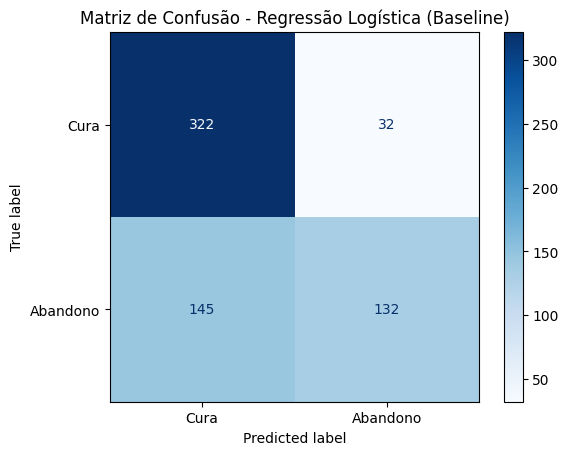

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Carregar o arquivo de teste (certifique-se de que o caminho está correto)
df_teste1 = pd.read_csv('./teste1.csv', encoding='latin1')

# 2. Separar X e y do teste usando os mesmos preditores do treino
# Importante: usamos a lista 'preditores_selecionados' que definimos antes
X_test1 = df_teste1.drop('ltfu', axis=1)
y_test1 = df_teste1['ltfu']

# 3. Fazer as predições usando o pipeline treinado
y_pred = baseline_pipeline.predict(X_test1)
y_proba = baseline_pipeline.predict_proba(X_test1)[:, 1] # Probabilidade de abandono

# 4. Gerar o Relatório de Métricas
print("--- Relatório de Classificação (Teste 1) ---")
print(classification_report(y_test1, y_pred))

# 5. Visualizar a Matriz de Confusão (Fundamental para o Relatório Científico)
print("--- Matriz de Confusão ---")
cm = confusion_matrix(y_test1, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Cura', 'Abandono'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - Regressão Logística (Baseline)')
plt.show()

In [ ]:
from sklearn.utils import class_weight
import numpy as np

# Calcular os pesos de classe
# 'balanced' ajusta os pesos inversamente proporcionais às frequências da classe
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)

# Converter para um dicionário para ser usado pelo Keras
class_weights_dict = dict(enumerate(class_weights))

print("Pesos de classe calculados:", class_weights_dict)

Pesos de classe calculados: {0: np.float64(0.6204888635972632), 1: np.float64(2.574880553572409)}


In [ ]:
import keras
from keras import layers, regularizers

# Arquitetura da rede
modelo = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),

    layers.Dense(256, kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),

    layers.Dense(128, kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.2),

    layers.Dense(64, kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.1),

    layers.Dense(32),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(1, activation='sigmoid')
])

# compilação do modelo
modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc')]
)

#modelo.summary()

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report

# 1. Preparar os dados (Transformar X usando o preprocessor que já criamos)
# A rede neural precisa de matrizes numéricas puras na entrada
X_train_transformed = baseline_pipeline.named_steps['preprocessor'].transform(X)
X_test1_transformed = baseline_pipeline.named_steps['preprocessor'].transform(X_test1)

# 2. Definir a Arquitetura da Rede Neural
model = Sequential([
    # Camada de entrada (ajustada automaticamente ao número de colunas após o OneHot)
    Dense(64, activation='relu', input_shape=(X_train_transformed.shape[1],)),
    Dropout(0.2), # Para evitar Overfitting

    # Camada Oculta
    Dense(32, activation='relu'),
    Dropout(0.2),

    # Camada de Saída (Sigmoid é ideal para classificação binária 0 ou 1)
    Dense(1, activation='sigmoid')
])

# 3. Compilar o Modelo
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['Recall'] # Focamos em Recall por ser um problema de saúde
)

# 4. Treinar a Rede Neural
print("Iniciando o treinamento da Rede Neural...")
history = model.fit(
    X_train_transformed, y,
    epochs=20,
    batch_size=32,
    validation_split=0.2, # Reserva 20% do treino para validar durante as épocas
    verbose=1,
    class_weight=class_weights_dict # Adiciona os pesos de classe
)

# 5. Avaliação no Teste 1
y_pred_nn = (model.predict(X_test1_transformed) > 0.5).astype(int)

print("\n--- Relatório de Classificação: Rede Neural ---")
print(classification_report(y_test1, y_pred_nn))

C:\Users\izzuz\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iniciando o treinamento da Rede Neural...
Epoch 1/20
14066/14066 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step - Recall: 0.6614 - loss: 0.5545 - val_Recall: 0.7400 - val_loss: 0.5756
Epoch 2/20
14066/14066 ━━━━━━━━━━━━━━━━━━━━ 18s 1ms/step - Recall: 0.6668 - loss: 0.5463 - val_Recall: 0.7354 - val_loss: 0.5844
Epoch 3/20
14066/14066 ━━━━━━━━━━━━━━━━━━━━ 18s 1ms/step - Recall: 0.6716 - loss: 0.5445 - val_Recall: 0.7270 - val_loss: 0.5717
Epoch 4/20
14066/14066 ━━━━━━━━━━━━━━━━━━━━ 18s 1ms/step - Recall: 0.6775 - loss: 0.5427 - val_Recall: 0.7326 - val_loss: 0.5693
Epoch 5/20
14066/14066 ━━━━━━━━━━━━━━━━━━━━ 18s 1ms/step - Recall: 0.6772 - loss: 0.5423 - val_Recall: 0.7126 - val_loss: 0.5515
Epoch 6/20
14066/14066 ━━━━━━━━━━━━━━━━━━━━ 18s 1ms/step - Recall: 0.6778 - loss: 0.5413 - val_Recall: 0.7147 - val_loss: 0.5561
Epoch 7/20
14066/14066 ━━━━━━━━━━━━━━━━━━━━ 19s 1ms/step - Recall: 0.6784 - loss: 0.5411 - val_Recall: 0.7521 - val_loss: 0.5826
Epoch 8/20
14066/14066 ━━━━━━━━━━━━━━━━━━━━ 19s 1ms/ste

In [ ]:
model.save('modelo_redeneural_tuberculose_vFinal_treino2.keras')
print("✅ Modelo de Rede Neural exportado como 'modelo_redeneural_tuberculose_vFinal_treino2.keras'")

✅ Modelo de Rede Neural exportado como 'modelo_redeneural_tuberculose_vFinal_treino2.keras'


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers, regularizers
from sklearn.metrics import classification_report

# 1. Preparar os dados (Transformar X e X_test1 usando o preprocessor)
# O preprocessor já está definido dentro do baseline_pipeline
X_train_transformed = baseline_pipeline.named_steps['preprocessor'].transform(X)
X_test1_transformed = baseline_pipeline.named_steps['preprocessor'].transform(X_test1)

# 2. Definir a Arquitetura da Rede Neural (do primeiro modelo, mais robusto)
robust_model = Sequential([
    layers.Input(shape=(X_train_transformed.shape[1],)),

    layers.Dense(256, kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),

    layers.Dense(128, kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.2),

    layers.Dense(64, kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.1),

    layers.Dense(32),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(1, activation='sigmoid')
])

# 3. Compilar o Modelo (do segundo modelo, com foco em Recall e Adam padrão)
robust_model.compile(
    optimizer='adam', # Adam com learning rate padrão (0.001)
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.Recall(name='recall')] # Focar no Recall
)

# 4. Treinar a Rede Neural (do segundo modelo, com class_weights)
print("Iniciando o treinamento da Rede Neural Combinada...")
history_combined = robust_model.fit(
    X_train_transformed, y,
    epochs=150, # Manter o número de épocas da segunda rede
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    class_weight=class_weights_dict # Usar os pesos de classe calculados
)

In [ ]:
# 5. Avaliação no Teste 1
y_pred_combined = (robust_model.predict(X_test1_transformed) > 0.5).astype(int)

print("\n--- Relatório de Classificação: Rede Neural Combinada ---")
print(classification_report(y_test1, y_pred_combined))

In [ ]:
from sklearn.metrics import precision_score, f1_score, roc_auc_score, accuracy_score

# As predições binárias já foram feitas na célula anterior (ovP5YjQ6xHgC):
# y_pred_combined = (robust_model.predict(X_test1_transformed) > 0.5).astype(int)

# Precisamos das probabilidades para calcular a AUC-ROC
y_proba_combined = robust_model.predict(X_test1_transformed).flatten()

# 1. Calcular Precisão
precision = precision_score(y_test1, y_pred_combined)

# 2. Calcular F1-Score
f1 = f1_score(y_test1, y_pred_combined)

# 3. Calcular AUC-ROC
auc_roc = roc_auc_score(y_test1, y_proba_combined)

# 4. Acurácia (já está no classification_report, mas podemos destacar)
accuracy = accuracy_score(y_test1, y_pred_combined)

print("\n--- Métricas Adicionais para a Rede Neural Combinada ---")
print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# 1. Extrair os dados transformados (X_test1 já processado)
X_test1_transformed = baseline_pipeline.named_steps['preprocessor'].transform(X_test1)

# 2. Obter o modelo treinado de dentro do pipeline
model_logreg = baseline_pipeline.named_steps['classifier']

# 3. Criar o Explainer focado no MODELO (LinearExplainer é perfeito para Regressão Logística)
# Ele é muito mais rápido e estável que o KernelExplainer
explainer = shap.LinearExplainer(model_logreg, X_test1_transformed)
shap_values = explainer.shap_values(X_test1_transformed)

# 4. Recuperar os nomes das colunas para o gráfico ficar legível
# Vamos pegar os nomes que o OneHotEncoder criou
cat_encoder = baseline_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_names = cat_encoder.get_feature_names_out(cat_features).tolist()
feature_names_final = num_features + cat_names + ordinal_features

# 5. Gerar o gráfico de importância (Summary Plot)
print("Gerando gráfico SHAP...")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test1_transformed, feature_names=feature_names_final)
plt.show()

In [ ]:
# 1. Carregar o teste final
df_teste2 = pd.read_csv('./teste2.csv', encoding='latin1')

# 2. Separar preditores e alvo
# Nota: o pipeline já sabe tratar as colunas e converter para string automaticamente
X_test2 = df_teste2.drop('ltfu', axis=1)
y_test2 = df_teste2['ltfu']

# 3. Predição e Métricas Finais
#y_pred2 = model.predict(X_test2)
y_pred2 = (model.predict(X_test2) > 0.5).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print("--- 🏆 RESULTADO FINAL DEFINITIVO (TESTE 2) ---")
print(classification_report(y_test2, y_pred2))

# Matriz de Confusão Final
print("--- Matriz de Confusão Final ---")
print(confusion_matrix(y_test2, y_pred2))

ValueError: Invalid dtype: object

In [ ]:
import joblib
joblib.dump(baseline_pipeline, 'modelo_tuberculose_v2.pkl')

Checklist
 - [x] Preparacao dos dados
 - [x] Beg.log + Rede Neural
 - [x] Teste 1
 - [x] Teste 2
 - [ ] API

Tarefas
 - [ ] Refatorar o codigo como um todo das transformacoes
 - [x] Treinar uma regressão logística básica sem hiperparametros
 - [ ] Treinar uma regressão logística tunado a regularização elasticnet

In [ ]:
import joblib
import pandas as pd

def cast_to_str(X):
    return pd.DataFrame(X).astype(str).replace('nan', 'ignorado')

# 1. Carregar o pipeline completo (que já inclui o preprocessor)
pipeline_final_v1 = joblib.load('modelo_tuberculose_v1.pkl')
pipeline_final_v2 = joblib.load('modelo_tuberculose_v2.pkl')

# 2. Simulação de um JSON recebido do seu Frontend/API
dados_paciente_frontend = {
    'idade_anos': 35,
    'CS_SEXO': 'M',
    'CS_GESTANT': '6',
    'CS_RACA': '1',
    'CS_ESCOL_N': '3',
    'SG_UF': '35',
    'TRATAMENTO': '1',
    'POP_LIBER': '2',
    'POP_RUA': '2',
    'POP_SAUDE': '2',
    'POP_IMIG': '2',
    'FORMA': '1',
    'AGRAVALCOO': '2',
    'AGRAVDIABE': '2',
    'AGRAVDOENC': '2',
    'AGRAVOUTRA': '2',
    'HIV': '2',
    'SG_UF_2': '35',
    'TRATSUP_AT': '1',
    'TRANSF': '2'
}

# 3. Converter para DataFrame (necessário para o pipeline)
# Nota: O pipeline precisa das mesmas colunas usadas no treinamento
novo_paciente_df = pd.DataFrame([dados_paciente_frontend])

# 4. Obter a probabilidade
# predict_proba retorna [prob_classe_0, prob_classe_1]
probabilidades_v1 = pipeline_final_v1.predict_proba(novo_paciente_df)
probabilidades_v2 = pipeline_final_v2.predict_proba(novo_paciente_df)
prob_abandono_v1 = probabilidades_v1[0][1] * 100
prob_abandono_v2 = probabilidades_v2[0][1] * 100

print(f"Resultado para o médico: O paciente tem {prob_abandono_v1:.2f}% de chance de abandonar o tratamento.")
print(f"Resultado para o médico: O paciente tem {prob_abandono_v2:.2f}% de chance de abandonar o tratamento.")

if prob_abandono > 70:
    print("Recomendação: Alerta de alto risco! Iniciar busca ativa ou suporte psicossocial.")

ValueError: <class 'numpy.random._mt19937.MT19937'> is not a known BitGenerator module.

In [ ]:
import tensorflow as tf
import joblib
import pandas as pd

# Carrega a inteligência de pré-processamento (do pipeline v2 que já salvamos)
pipeline_base = joblib.load('baseline_pipeline_treino2.pkl')
prep = pipeline_base.named_steps['preprocessor']

# Carrega a Rede Neural
modelo_carregado = tf.keras.models.load_model('modelo_redeneural_tuberculose_vFinal_treino2.keras')

# 2. Simulação de um JSON recebido do seu Frontend/API
dados_paciente_frontend = {
    'idade_anos': 35,
    'CS_SEXO': 'M',
    'CS_GESTANT': '6',
    'CS_RACA': '1',
    'CS_ESCOL_N': '3',
    'SG_UF': '35',
    'TRATAMENTO': '1',
    'POP_LIBER': '2',
    'POP_RUA': '2',
    'POP_SAUDE': '2',
    'POP_IMIG': '2',
    'FORMA': '1',
    'AGRAVALCOO': '2',
    'AGRAVDIABE': '2',
    'AGRAVDOENC': '2',
    'AGRAVOUTRA': '2',
    'HIV': '2',
    'SG_UF_2': '35',
    'TRATSUP_AT': '1',
    'TRANSF': '2'
}

# 3. Converter para DataFrame (necessário para o pipeline)
# Nota: O pipeline precisa das mesmas colunas usadas no treinamento
novo_paciente_df = pd.DataFrame([dados_paciente_frontend])

# Exemplo de predição
dados_transformados = prep.transform(novo_paciente_df)
probabilidade = modelo_carregado.predict(dados_transformados)
print(f"Probabilidade de abandono: {probabilidade[0][0]*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Probabilidade de abandono: 79.15%


In [ ]:
# regressão logística básica sem hiperparametros

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=12)
model.fit(X_train_transformed, y) # Corrigido: Usando 'y' em vez de 'y_train'

y_pred = model.predict(X_test1_transformed)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

model_elastic = LogisticRegression(
    penalty='elasticnet',
    solver='saga',        # único solver que suporta elasticnet
    random_state=12,
    max_iter=1000
)

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]  # 0 = Ridge, 1 = Lasso
}

grid_search = GridSearchCV(
    model_elastic,
    param_grid,
    scoring='f1',   # f1 por causa do desbalanceamento da classe ltfu
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_transformed, y)

print("Melhores parâmetros:", grid_search.best_params_)
print("Melhor F1:", grid_search.best_score_)

y_pred_elastic = grid_search.predict(X_test1_transformed)
print(classification_report(y_test1, y_pred_elastic))

KeyboardInterrupt: 

In [ ]:
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 1. Carregar o pipeline salvo anteriormente
pipeline_importado = baseline_pipeline

# 2. Extrair o preprocessor do pipeline carregado
preprocessor_base = pipeline_importado.named_steps['preprocessor']

# 3. Preparar os dados usando o preprocessor importado
X_train_prep = preprocessor_base.transform(X)
X_test1_prep = preprocessor_base.transform(X_test1)

# 4. Treinar Regressão Logística básica (sem hiperparâmetros de regularização específicos)
model_basico_importado = LogisticRegression(max_iter=1000, random_state=12)

print("Iniciando treinamento da Regressão Logística básica com dados importados...")
model_basico_importado.fit(X_train_prep, y)

# 5. Avaliação
y_pred_basico = model_basico_importado.predict(X_test1_prep)

print("\n--- Relatório de Classificação: Regressão Logística Básica (Pós-Importação) ---")
print(classification_report(y_test1, y_pred_basico))

Iniciando treinamento da Regressão Logística básica com dados importados...

--- Relatório de Classificação: Regressão Logística Básica (Pós-Importação) ---
              precision    recall  f1-score   support

           0       0.69      0.91      0.78       354
           1       0.80      0.48      0.60       277

    accuracy                           0.72       631
   macro avg       0.75      0.69      0.69       631
weighted avg       0.74      0.72      0.70       631



In [ ]:
import joblib

# Salvar o modelo de regressão logística básica
joblib.dump(model_basico_importado, 'modelo_regressao_basica_v1.pkl')

print("✅ Modelo de Regressão Logística exportado com sucesso para 'modelo_regressao_basica_v1.pkl'")

✅ Modelo de Regressão Logística exportado com sucesso para 'modelo_regressao_basica_v1.pkl'


Analise o relatorio de regressao logistica basica --- Relatório de Classificação: Regressão Logística Básica (Pós-Importação) --- precision recall f1-score support 0 0.69 0.91 0.78 354 1 0.80 0.48 0.60 277 accuracy 0.72 631 macro avg 0.75 0.69 0.69 631 weighted avg 0.74 0.72 0.70 631
Com base no relatório da Regressão Logística Básica, aqui está a análise de desempenho:

1. Desempenho por Classe
Classe 0 (Cura/Não Abandono): O modelo é muito eficiente em identificar quem não vai abandonar o tratamento, com um Recall de 0.91. Isso significa que 91% dos casos de cura são detectados corretamente. A precisão é de 0.69, o que indica alguns falsos positivos (pessoas que abandonariam, mas o modelo previu cura).
Classe 1 (Abandono): Aqui reside o principal desafio. Embora a Precisão seja alta (0.80) — ou seja, quando o modelo aponta abandono, ele acerta em 80% das vezes — o Recall é baixo (0.48). O modelo está detectando menos da metade (48%) dos pacientes que realmente abandonam o tratamento.
2. Visão Geral e Eficiência
Acurácia Global (0.72): O modelo acerta 72% do total de casos. É um valor razoável, mas mascarado pelo bom desempenho na classe 0.
F1-Score da Classe 1 (0.60): Este valor mostra que o modelo ainda não está equilibrado para a classe de interesse (Abandono).
Conclusão
Este modelo básico é conservador. Ele evita dar 'alarmes falsos' de abandono (alta precisão), mas deixa passar muitos pacientes em risco (baixo recall). No contexto de saúde pública, onde o objetivo é intervir preventivamente, este modelo pode ser considerado insuficiente, pois não identifica 52% dos pacientes que precisam de atenção.

É por isso que a abordagem com pesos de classe (que vimos na Rede Neural) ou a tunagem ElasticNet (que estamos fazendo) são fundamentais para tentar elevar esse Recall de 0.48 para patamares mais seguros.

In [ ]:
import joblib
import pandas as p
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# Funções de suporte para garantir uniformidade de tipos
def cast_to_str(X):
    return pd.DataFrame(X).astype(str).replace('nan', 'ignorado')

# 1. Carregar o pipeline base exportado anteriormente
pipeline_base = baseline_pipeline
preprocessor = pipeline_base.named_steps['preprocessor']

# 2. Transformar os dados usando o preprocessor base
X_train_prep = preprocessor.transform(X)
X_test1_prep = preprocessor.transform(X_test1)

# 3. Configurar o modelo para ElasticNet (exige o solver 'saga')
model_elastic = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    max_iter=2000,
    random_state=12
)

# 4. Definir a grade de hiperparâmetros
param_grid = {
    'C': [0.1, 1.0, 10.0],
    'l1_ratio': [0.2, 0.5, 0.8] # Proporção entre L1 e L2
}

# 5. Executar a busca (GridSearch)
grid_search = GridSearchCV(
    model_elastic,
    param_grid,
    scoring='recall',
    cv=3,
    n_jobs=-1
)

print("Iniciando tunagem ElasticNet...")
grid_search.fit(X_train_prep, y)

# 6. Resultados e Avaliação
print(f"\nMelhores Hiperparâmetros: {grid_search.best_params_}")
y_pred_elastic = grid_search.predict(X_test1_prep)

print("\n--- Relatório de Classificação: ElasticNet Tunado ---")
print(classification_report(y_test1, y_pred_elastic))

Iniciando tunagem ElasticNet...

Melhores Hiperparâmetros: {'C': 10.0, 'l1_ratio': 0.8}

--- Relatório de Classificação: ElasticNet Tunado ---
              precision    recall  f1-score   support

           0       0.69      0.91      0.79       354
           1       0.81      0.48      0.60       277

    accuracy                           0.72       631
   macro avg       0.75      0.69      0.69       631
weighted avg       0.74      0.72      0.70       631



In [ ]:
import joblib

# 1. Verificar se o grid_search foi concluído e extrair o melhor modelo
try:
    melhor_modelo_elastic = grid_search.best_estimator_

    # 2. Salvar o modelo
    joblib.dump(melhor_modelo_elastic, 'modelo_elasticnet_tunado_v1.pkl')
    print("✅ Modelo ElasticNet tunado exportado com sucesso como 'modelo_elasticnet_tunado_v1.pkl'")
except NameError:
    print("❌ Erro: O objeto 'grid_search' não foi encontrado. Certifique-se de rodar a célula de treinamento antes.")

✅ Modelo ElasticNet tunado exportado com sucesso como 'modelo_elasticnet_tunado_v1.pkl'


In [ ]:
melhor_modelo_elastic = grid_search.best_estimator_
prep = pipeline_base.named_steps['preprocessor']

modelo_carregado = tf.keras.models.load_model('modelo_redeneural_tuberculose_vFinal_treino2.keras')

# 2. Simulação de um JSON recebido do seu Frontend/API
dados_paciente_frontend = {
    'idade_anos': 35,
    'CS_SEXO': 'M',
    'CS_GESTANT': '6',
    'CS_RACA': '1',
    'CS_ESCOL_N': '3',
    'SG_UF': '35',
    'TRATAMENTO': '1',
    'POP_LIBER': '2',
    'POP_RUA': '2',
    'POP_SAUDE': '2',
    'POP_IMIG': '2',
    'FORMA': '1',
    'AGRAVALCOO': '2',
    'AGRAVDIABE': '2',
    'AGRAVDOENC': '2',
    'AGRAVOUTRA': '2',
    'HIV': '2',
    'SG_UF_2': '35',
    'TRATSUP_AT': '1',
    'TRANSF': '2'
}

# 3. Converter para DataFrame (necessário para o pipeline)
# Nota: O pipeline precisa das mesmas colunas usadas no treinamento
novo_paciente_df = pd.DataFrame([dados_paciente_frontend])

# Exemplo de predição
dados_transformados = prep.transform(novo_paciente_df)
probabilidade = modelo_carregado.predict(dados_transformados)
print(f"Probabilidade de abandono: {probabilidade[0][0]*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
Probabilidade de abandono: 79.15%
